In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Part 1 - environmental indexes  
As presentation was prepared in Russian in this part i use commentaries in Russian because here a lot of formulas but in other parts I'll use English

## Индекс загрязненности вод (ИЗВ)
Cредняя доля превышения ПДК по определенному числу индивидуальных ингредиентов. Для моря при расчете индекса используют четыре параметра с обязательным включением в этот список растворенного кислорода, а остальные выбирают по признаку наибольшей токсичности

$$ИЗВ_{n}=\frac{\sum\limits_{i=1}^n\frac{С_{i}}{ПДК_{i}}}{n}$$

### Пример расчета ИЗВ

In [2]:
times = pd.date_range(start='01-01-2025', freq='D', periods=365)
times_months = times.month

cu = np.random.normal(0.005, 0.0001, 365)
cd = np.random.uniform(0.005, 0.005,365)
hg = np.random.normal(0.00005, 0.00001, 365)
pb = np.random.uniform(0.005, 0.009,365)
nh4 = np.random.normal(2, 0.02, 365)
salinity = np.random.uniform(30,32,365)
oil = np.random.exponential(0.05, 365)
oxy = np.random.normal(6, 0.05, 365)

data_izv = pd.DataFrame({'date': times, 'month': times_months, 'cu': cu, 'cd': cd, 'hg': hg, 'pb': pb, 'nh4': nh4, 'salinity': salinity, 'oil': oil, 'oxy': oxy})
display(data_izv)

,date,month,cu,cd,hg,pb,nh4,salinity,oil,oxy
0,2025-01-01,1,0.005099,0.005,0.000046,0.008812,1.996099,31.108271,0.180996,6.001676
1,2025-01-02,1,0.005157,0.005,0.000043,0.008494,1.991765,31.904024,0.101146,6.012084
2,2025-01-03,1,0.004990,0.005,0.000050,0.006522,2.025557,30.220226,0.146641,6.045268
3,2025-01-04,1,0.005057,0.005,0.000053,0.007292,2.006592,30.784641,0.008596,6.015963
4,2025-01-05,1,0.004992,0.005,0.000034,0.005141,2.005049,31.666164,0.022934,5.957246
...,...,...,...,...,...,...,...,...,...,...
360,2025-12-27,12,0.004723,0.005,0.000025,0.007277,2.013948,30.038180,0.014369,6.011877
361,2025-12-28,12,0.005087,0.005,0.000045,0.007940,2.027668,30.848102,0.014305,6.034570
362,2025-12-29,12,0.005008,0.005,0.000055,0.005241,1.985599,31.991047,0.007154,5.947391
363,2025-12-30,12,0.005120,0.005,0.000051,0.005175,2.007057,30.001105,0.255032,5.993502


In [3]:
pdk_voc = {'cu':0.005, 'cd': 0.01, 'hg': 0.0001, 'pb': 0.01, 'nh4': 2.9, 'oil': 0.05}
display(pdk_voc)

{'cu': 0.005, 'cd': 0.01, 'hg': 0.0001, 'pb': 0.01, 'nh4': 2.9, 'oil': 0.05}

In [4]:
def izv(data, pdk_voc):
    izv_list = []
    data_proc = data[['date', 'month']]
    for i in pdk_voc.keys():
        data_proc[i] = data[i] / pdk_voc[i]
    data_proc['oxy'] = 6 / data['oxy']
    data_proc2 = data_proc.drop(['date', 'month'], axis=1)
    data_proc2 = data_proc2.T

    for b in data_proc2.columns:
        temp = np.array(data_proc2.loc[data_proc2[b] > 1][b])
        try:
            h = np.sort(temp)[::-1][0:5]
            h = np.sum(h)
            izv_list.append(h)
        except:
            izv_list.append(None)
    data['izv'] = izv_list
    return data

In [5]:
data_izv = izv(data_izv, pdk_voc)

C:\Users\vladk\AppData\Local\Temp\ipykernel_4792\432567316.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_proc[i] = data[i] / pdk_voc[i]
C:\Users\vladk\AppData\Local\Temp\ipykernel_4792\432567316.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_proc[i] = data[i] / pdk_voc[i]
C:\Users\vladk\AppData\Local\Temp\ipykernel_4792\432567316.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

In [6]:
def izv_cat(row):
    if row < 0.25:
        return 'very_clear'
    if row < 0.75:
        return 'clear' 
    if row < 1.25:
        return 'moderate_dirty'
    if row < 1.75:
        return 'partly_dirty'
    if row < 3:
        return 'dirty'
    if row < 5:
        return 'very_dirty'
    else:
        return 'very_very_dirty'

In [7]:
def izv_cat_class(row):
    if row < 0.25:
        return 'I'
    if row < 0.75:
        return 'II' 
    if row < 1.25:
        return 'III'
    if row < 1.75:
        return 'IV'
    if row < 3:
        return 'V'
    if row < 5:
        return 'VI'
    else:
        return 'VII'

In [8]:
data_izv['izv_cat'] = data_izv['izv'].apply(izv_cat)
data_izv['izv_cat_class'] = data_izv['izv'].apply(izv_cat_class)

In [9]:
display(data_izv)

,date,month,cu,cd,hg,pb,nh4,salinity,oil,oxy,izv,izv_cat,izv_cat_class
0,2025-01-01,1,0.005099,0.005,0.000046,0.008812,1.996099,31.108271,0.180996,6.001676,4.639779,very_dirty,VI
1,2025-01-02,1,0.005157,0.005,0.000043,0.008494,1.991765,31.904024,0.101146,6.012084,3.054357,very_dirty,VI
2,2025-01-03,1,0.004990,0.005,0.000050,0.006522,2.025557,30.220226,0.146641,6.045268,2.932828,dirty,V
3,2025-01-04,1,0.005057,0.005,0.000053,0.007292,2.006592,30.784641,0.008596,6.015963,1.011381,moderate_dirty,III
4,2025-01-05,1,0.004992,0.005,0.000034,0.005141,2.005049,31.666164,0.022934,5.957246,1.007177,moderate_dirty,III
...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,2025-12-27,12,0.004723,0.005,0.000025,0.007277,2.013948,30.038180,0.014369,6.011877,0.000000,very_clear,I
361,2025-12-28,12,0.005087,0.005,0.000045,0.007940,2.027668,30.848102,0.014305,6.034570,1.017306,moderate_dirty,III
362,2025-12-29,12,0.005008,0.005,0.000055,0.005241,1.985599,31.991047,0.007154,5.947391,2.010401,dirty,V
363,2025-12-30,12,0.005120,0.005,0.000051,0.005175,2.007057,30.001105,0.255032,5.993502,7.125740,very_very_dirty,VII


(array([ 53., 117., 116.,   0.,  11.,  59.,   9.]),
 array([0.        , 0.71428571, 1.42857143, 2.14285714, 2.85714286,
        3.57142857, 4.28571429, 5.        ]),
 <BarContainer object of 7 artists>)

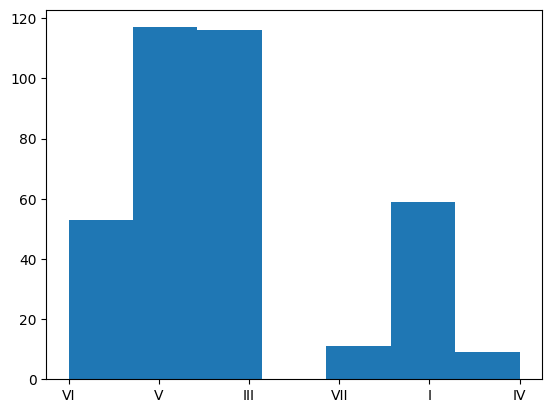

In [10]:
plt.hist(data=data_izv, x='izv_cat_class', bins=7)

(array([ 53., 117., 116.,   0.,  11.,  59.,   9.]),
 array([0.        , 0.71428571, 1.42857143, 2.14285714, 2.85714286,
        3.57142857, 4.28571429, 5.        ]),
 <BarContainer object of 7 artists>)

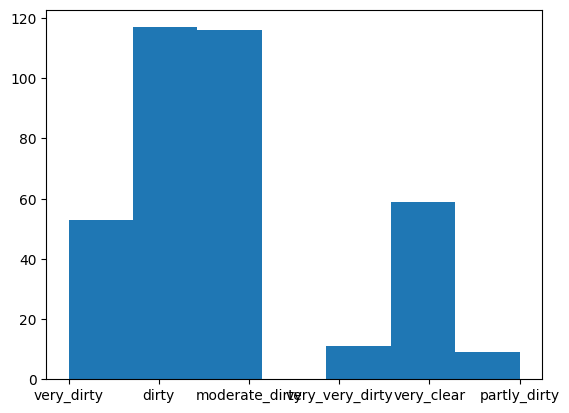

In [11]:
plt.hist(data=data_izv, x='izv_cat', bins=7)

## Суммарный показатель химического загрязнения $З_{ц}$
Характеризует степень химического загрязнения грунтов. $K_{ci}$ - коэффициент концентрации i-го химического элемента, равный кратности превышения его содержания над фоновым значением. n - число определяемых суммируемых веществ с $K_{ci}$ > 1. Если по по всем химическим элементам отсутствуют превышения над их фоновыми значениями, расчет $З_{ц}$ не выполняют.


$$З_{ц}=\sum\limits_{i=1}^n(K_{ci} + ... + K_{cn}) - (n-1)$$

## Pollution Load Index (PLI), применяют как для вод, так и для осадков. 
Расчет похож на два вышеупомянутых (Зц, ИЗВ) только отношения загрязнителей к фону не суммируются, а перемножаются после чего из их произведения извлекается корень степени равной числу перемноженных показателей.


$$PLI=\sqrt[n]{K_{ci} + ... + K_{cn}}$$

## Индекс загрязнения атмосферы (ИЗА)
Характеризует степень загрязнения воздуха, рассчет почти аналогичен ИЗВ
где $C_{i}$ - средняя концентрация i-го вещества; $ПДК_{i}$ - среднесуточная ПДК i-го вещества; $K_{i}$ - безразмерная константа приведения степени вредности вещества к вредности диоксида серы

$$ИЗА_{5}=\sum\limits_{i=1}^n\frac{С_{i}}{ПДК_{i}}K_{i}$$

In [12]:
iza_support = pd.DataFrame({'danger_class' : [1,2,3,4],
                         'class_description' : ['extreme dangerous', 'high dangerous', 'dangerous', 'low dangerous'],
                         'k_i' : [1.5,1.3,1,0.85]}
    )
iza_support

,danger_class,class_description,k_i
0,1,extreme dangerous,1.50
1,2,high dangerous,1.30
2,3,dangerous,1.00
3,4,low dangerous,0.85


In [13]:
iza_support2 = pd.DataFrame({'iza_5' : ['0-5','5-7','7-14','>14'],
                         'pollution degree' : ['low', 'moderate', 'high', 'extreme']}
    )
iza_support2

,iza_5,pollution degree
0,0-5,low
1,5-7,moderate
2,7-14,high
3,>14,extreme


### Пример расчета ИЗА

In [14]:
pdk_data = pd.DataFrame({'pdk_daily' : [3,0.05,0.04,0.06,0.04,0.000001,0.03],
                         'danger_class' : [4,3,3,3,4,1,1],
                         'k_i' : [0.85,1,1,1,0.85,1.5,1.5],
                         'param': ['CO','SO2','NO2','NO','NH3','BZ','O3']}
    ).set_index('param')

pdk_data

,pdk_daily,danger_class,k_i
param,,,
CO,3.000000,4,0.85
SO2,0.050000,3,1.00
NO2,0.040000,3,1.00
NO,0.060000,3,1.00
NH3,0.040000,4,0.85
BZ,0.000001,1,1.50
O3,0.030000,1,1.50


In [15]:
times = pd.date_range(start='01-01-2025', freq='D', periods=365)
times_months = times.month

co = np.random.normal(2, 0.5, 365)
so2 = np.random.uniform(0.04, 0.04, 365)
no2 = np.random.normal(0.0005, 0.0008, 365)
no = np.random.uniform(0.02, 0.3,365)
nh3 = np.random.normal(0.05, 0.02, 365)
bz = np.random.uniform(0.00000003, 0.00000005,365)
o3 = np.random.normal(0.02, 0.01, 365)

data_iza = pd.DataFrame({'date': times, 'month': times_months, 'CO': co, 'SO2': so2, 'NO2': no2, 'NO': no, 'NH3': nh3, 'BZ': bz, 'O3': o3})
display(data_iza)

,date,month,CO,SO2,NO2,NO,NH3,BZ,O3
0,2025-01-01,1,1.668782,0.04,0.000525,0.040389,0.075367,3.161085e-08,0.024224
1,2025-01-02,1,1.278190,0.04,0.000238,0.094194,0.048297,4.548157e-08,0.034770
2,2025-01-03,1,2.304566,0.04,0.000672,0.102989,0.055805,4.297486e-08,0.024509
3,2025-01-04,1,2.841645,0.04,0.001343,0.236866,0.085446,3.616775e-08,0.030117
4,2025-01-05,1,2.312759,0.04,0.001630,0.044236,0.046987,4.518167e-08,0.020312
...,...,...,...,...,...,...,...,...,...
360,2025-12-27,12,2.538852,0.04,0.001113,0.166179,0.084634,3.915838e-08,0.024159
361,2025-12-28,12,2.574012,0.04,0.000144,0.039774,0.034557,3.291111e-08,0.009672
362,2025-12-29,12,1.099590,0.04,0.000784,0.022992,0.071989,3.011206e-08,0.044816
363,2025-12-30,12,2.104968,0.04,0.000233,0.199588,0.038950,4.569118e-08,0.017579


In [16]:
pdk_daily = pdk_data['pdk_daily'].to_dict()
print(pdk_daily)
pdk_ki = pdk_data['k_i'].to_dict()
print(pdk_ki)

{'CO': 3.0, 'SO2': 0.05, 'NO2': 0.04, 'NO': 0.06, 'NH3': 0.04, 'BZ': 1e-06, 'O3': 0.03}
{'CO': 0.85, 'SO2': 1.0, 'NO2': 1.0, 'NO': 1.0, 'NH3': 0.85, 'BZ': 1.5, 'O3': 1.5}


In [17]:
%%time
def iza(data, pdk_daily, pdk_ki):
    iza_list = []
    for i in data.index:
        temp = data.loc[data.index == i].drop(['date', 'month'], axis=1)
        temp = temp / pdk_daily
        lam = lambda x: x if x > 1 else 0
        for a in temp.columns:
            temp[a] = temp[a].apply(lam)
        temp = temp * pdk_ki
        temp2 = np.array(temp[:1])    
        temp2 = np.sort(temp2)[::-1][:5]
        temp2 = np.sum(temp2)
        iza_list.append(temp2)
    return iza_list

data_iza['iza'] = iza(data_iza, pdk_daily, pdk_ki)

CPU times: total: 2.27 s
Wall time: 2.77 s


In [18]:
%%time
def iza_cat(row):
    if row < 5:
        return 'low'
    if row < 7:
        return 'moderate'
    if row < 14:
        return 'high'
    else:
        return 'very_high'

data_iza['iza_cat'] = data_iza['iza'].apply(iza_cat)
data_iza

CPU times: total: 0 ns
Wall time: 4 ms


,date,month,CO,SO2,NO2,NO,NH3,BZ,O3,iza,iza_cat
0,2025-01-01,1,1.668782,0.04,0.000525,0.040389,0.075367,3.161085e-08,0.024224,1.601549,low
1,2025-01-02,1,1.278190,0.04,0.000238,0.094194,0.048297,4.548157e-08,0.034770,4.334706,low
2,2025-01-03,1,2.304566,0.04,0.000672,0.102989,0.055805,4.297486e-08,0.024509,2.902344,low
3,2025-01-04,1,2.841645,0.04,0.001343,0.236866,0.085446,3.616775e-08,0.030117,7.269330,high
4,2025-01-05,1,2.312759,0.04,0.001630,0.044236,0.046987,4.518167e-08,0.020312,0.998473,low
...,...,...,...,...,...,...,...,...,...,...,...
360,2025-12-27,12,2.538852,0.04,0.001113,0.166179,0.084634,3.915838e-08,0.024159,4.568116,low
361,2025-12-28,12,2.574012,0.04,0.000144,0.039774,0.034557,3.291111e-08,0.009672,0.000000,low
362,2025-12-29,12,1.099590,0.04,0.000784,0.022992,0.071989,3.011206e-08,0.044816,3.770563,low
363,2025-12-30,12,2.104968,0.04,0.000233,0.199588,0.038950,4.569118e-08,0.017579,3.326474,low


(array([278.,   8.,  79.]),
 array([0.        , 0.66666667, 1.33333333, 2.        ]),
 <BarContainer object of 3 artists>)

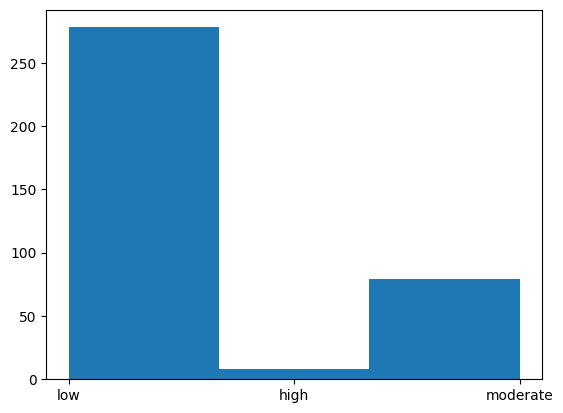

In [19]:
plt.hist(data=data_iza, x='iza_cat', bins=3)

In [20]:
## AQI test

## AQI - air quality index
про AQI в презентации не было, но пример интересный, поэтому тут описан

AQI рассчитвают пошагово:$
- используются данные по газам $NO_{2}$, $O_{3}$, $SO_{2}$, $CO$ и взвешенным частицам размеров 2.5 и 10 микрон - PM2.5 и PM10
- расчет делают для каждого из 6 показателей - общим AQI будет самый худший из результатов
- для каждого вещества выбирают интервал (в таблице aqi_support) и с учетом границ интервала и соответствующим $I_{high}$ и $I_{low}$ проводяят расчет частного AQI для вещества (субиндекса)

$$AQI_{sub}=\frac{I_{high}-I_{low}}{B_{high}-B_{low}}(C-B_{low})+I_{low}$$

$I_{high}$ и $I_{low}$ - соотвествующие границы индексов в таблице, $B_{high}$ и $B_{low}$ - соответствующие интервалы концентрации вещества, C - реальная концентрация вещества

In [21]:
aqi_support = pd.DataFrame({'O3_min': [0, 55, 71, 86, 106, None], 
                            'O3_max': [54, 70, 85, 105, 200, None],
                            'PM_25_min': [0, 9.1, 35.5, 55.5, 125.5, 225.5], 
                            'PM_25_max': [9.0, 35.4, 55.4, 125.4, 225.4, 325.4], 
                            'PM_10_min': [0, 55, 155, 255, 355, 425], 
                            'PM_10_max': [54, 154, 254, 354, 424, 604], 
                            'CO_min': [0, 4.5, 9.5, 12.5, 15.5, 30.5], 
                            'CO_max': [4.4, 9.4, 12.4, 15.4, 30.4, 50.4],
                            'SO2_min': [0, 36, 76, 186, 305, 605], 
                            'SO2_max': [35, 75, 185, 304, 604, 1004],
                            'NO2_min': [0, 54, 101, 361, 650, 1250], 
                            'NO2_max': [53, 100, 360, 649, 1249, 2049],
                            'I_high': [0, 51, 101, 151, 201, 301],
                            'I_low': [50, 100, 150, 200, 300, 500],
                            'category': ['good', 'moderate', 'unhealthy_groups', 'unhealthy', 'very_unhealthy', 'hazardous']
                            })

display(aqi_support)

,O3_min,O3_max,PM_25_min,PM_25_max,PM_10_min,PM_10_max,CO_min,CO_max,SO2_min,SO2_max,NO2_min,NO2_max,I_high,I_low,category
0,0.0,54.0,0.0,9.0,0,54,0.0,4.4,0,35,0,53,0,50,good
1,55.0,70.0,9.1,35.4,55,154,4.5,9.4,36,75,54,100,51,100,moderate
2,71.0,85.0,35.5,55.4,155,254,9.5,12.4,76,185,101,360,101,150,unhealthy_groups
3,86.0,105.0,55.5,125.4,255,354,12.5,15.4,186,304,361,649,151,200,unhealthy
4,106.0,200.0,125.5,225.4,355,424,15.5,30.4,305,604,650,1249,201,300,very_unhealthy
5,NaN,NaN,225.5,325.4,425,604,30.5,50.4,605,1004,1250,2049,301,500,hazardous


### Пример расчета AQI

In [22]:
times = pd.date_range(start='01-01-2025', freq='D', periods=365)
times_months = times.month

o3_8 = np.random.normal(70, 10, 365)
pm_25_24 = np.random.uniform(0.1, 200,365)
pm_10_24 = np.random.normal(150, 50, 365)
co_8 = np.random.uniform(0, 40, 365)
so2_1 = np.random.normal(40, 10, 365)
no2_1 = np.random.uniform(10, 800,365)

data_aqi = pd.DataFrame({'date': times, 'month': times_months, 'O3': o3_8, 'PM_25': pm_25_24, 'PM_10': pm_10_24, 'CO': co_8, 'SO2': so2_1, 'NO2': no2_1})
display(data_aqi)

,date,month,O3,PM_25,PM_10,CO,SO2,NO2
0,2025-01-01,1,54.392766,9.655705,136.915402,37.181469,27.048621,574.058605
1,2025-01-02,1,80.075701,29.674751,130.699736,28.969225,53.091435,469.241996
2,2025-01-03,1,70.233420,134.289838,104.752032,32.604389,51.626062,384.379251
3,2025-01-04,1,87.108219,69.353558,192.906062,25.012568,20.159295,516.667718
4,2025-01-05,1,70.881811,107.093693,144.583549,24.846408,39.794105,288.300284
...,...,...,...,...,...,...,...,...
360,2025-12-27,12,75.935560,29.922985,70.045242,30.641085,42.006522,433.401146
361,2025-12-28,12,68.173043,95.218249,182.682179,12.797231,25.175280,13.619676
362,2025-12-29,12,62.522512,150.673864,204.389542,28.389781,54.104662,276.188311
363,2025-12-30,12,72.677083,102.433485,111.595094,1.350050,55.551176,435.894417


In [23]:
def aqi_cat(row):
    if row < 51:
        return 'good'
    if row < 101:
        return 'moderate'
    if row < 151:
        return 'unhealthy_groups'
    if row < 201:
        return 'unhealthy'
    if row < 301:
        return 'very_unhealthy'
    else:
        return 'hazardous'

In [24]:
def aqi_index_digits(data):
    aqi_support = pd.DataFrame({'O3_min': [0, 55, 71, 86, 106, None], 
                            'O3_max': [54, 70, 85, 105, 200, None],
                            'PM_25_min': [0, 9.1, 35.5, 55.5, 125.5, 225.5], 
                            'PM_25_max': [9.0, 35.4, 55.4, 125.4, 225.4, 325.4], 
                            'PM_10_min': [0, 55, 155, 255, 355, 425], 
                            'PM_10_max': [54, 154, 254, 354, 424, 604], 
                            'CO_min': [0, 4.5, 9.5, 12.5, 15.5, 30.5], 
                            'CO_max': [4.4, 9.4, 12.4, 15.4, 30.4, 50.4],
                            'SO2_min': [0, 36, 76, 186, 305, 605], 
                            'SO2_max': [35, 75, 185, 304, 604, 1004],
                            'NO2_min': [0, 54, 101, 361, 650, 1250], 
                            'NO2_max': [53, 100, 360, 649, 1249, 2049],
                            'I_low': [0, 51, 101, 151, 201, 301],
                            'I_high': [50, 100, 150, 200, 300, 500],
                            'category': ['good', 'moderate', 'unhealthy_groups', 'unhealthy', 'very_unhealthy', 'hazardous']
                            })

    aqi_indexes_list = []
    for i in data.index:
        temp = data.loc[data.index == i].drop(['date', 'month'], axis=1)
        temp = temp[['O3', 'PM_25', 'PM_10', 'CO', 'NO2', 'SO2']]
        temp = temp.reset_index(drop=True)
        list_for_row = []
        for n in temp.columns:
            target = temp[n][0]
            aqi_support_temp = aqi_support.loc[aqi_support['category'] == temp[n].apply(aqi_cat)[0]]
            
            c_low = n + '_min'
            c_high = n + '_max'

            aqi_hear = ((aqi_support_temp['I_high'] - aqi_support_temp['I_low']) / (aqi_support_temp[c_high] - aqi_support_temp[c_low])) * (target - aqi_support_temp[c_low]) + aqi_support_temp['I_low']

            list_for_row.append(aqi_hear)
        
        index_for_st = np.max(list_for_row)
        aqi_indexes_list.append(index_for_st)
    return aqi_indexes_list

In [25]:
%%time
data_aqi['aqi_digits'] = aqi_index_digits(data_aqi)
data_aqi['aqi_categoty'] = data_aqi['aqi_digits'].apply(aqi_cat)
data_aqi

CPU times: total: 4.91 s
Wall time: 6.18 s


,date,month,O3,PM_25,PM_10,CO,SO2,NO2,aqi_digits,aqi_categoty
0,2025-01-01,1,54.392766,9.655705,136.915402,37.181469,27.048621,574.058605,422.516694,hazardous
1,2025-01-02,1,80.075701,29.674751,130.699736,28.969225,53.091435,469.241996,329.195740,hazardous
2,2025-01-03,1,70.233420,134.289838,104.752032,32.604389,51.626062,384.379251,370.504415,hazardous
3,2025-01-04,1,87.108219,69.353558,192.906062,25.012568,20.159295,516.667718,284.233728,very_unhealthy
4,2025-01-05,1,70.881811,107.093693,144.583549,24.846408,39.794105,288.300284,282.345549,very_unhealthy
...,...,...,...,...,...,...,...,...,...,...
360,2025-12-27,12,75.935560,29.922985,70.045242,30.641085,42.006522,433.401146,348.194147,hazardous
361,2025-12-28,12,68.173043,95.218249,182.682179,12.797231,25.175280,13.619676,211.448449,very_unhealthy
362,2025-12-29,12,62.522512,150.673864,204.389542,28.389781,54.104662,276.188311,384.593936,hazardous
363,2025-12-30,12,72.677083,102.433485,111.595094,1.350050,55.551176,435.894417,265.811094,very_unhealthy


(array([167., 147.,   0.,  34.,  16.,   1.]),
 array([0.        , 0.66666667, 1.33333333, 2.        , 2.66666667,
        3.33333333, 4.        ]),
 <BarContainer object of 6 artists>)

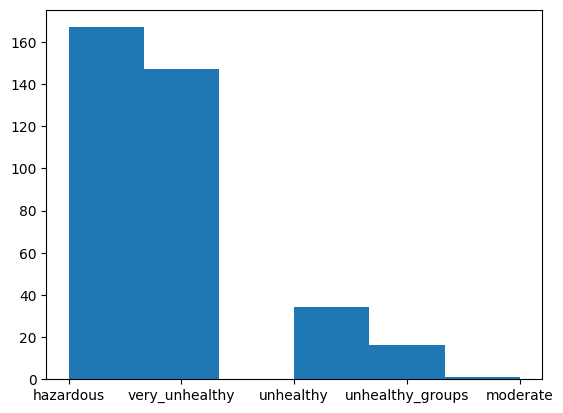

In [26]:
plt.hist(data=data_aqi, x='aqi_categoty', bins=6)

## Trophic State Index - TSI
предназначен для оценки водных объектов на основе уровня биологической продуктивности (олиготрофный, мезотрофный, эвтрофный, гиперэвтрофный)

$$TSI=9.81ln(CHL)-30.6$$

### Пример расчета TSI

In [27]:
times = pd.date_range(start='01-01-2025', freq='D', periods=365)
times_months = times.month

chl = np.random.normal(10, 5, 365)

data_chl = pd.DataFrame({'date': times, 'month': times_months, 'chl': chl})
display(data_chl)

,date,month,chl
0,2025-01-01,1,17.986498
1,2025-01-02,1,3.342686
2,2025-01-03,1,11.087198
3,2025-01-04,1,11.606362
4,2025-01-05,1,15.066293
...,...,...,...
360,2025-12-27,12,15.980769
361,2025-12-28,12,11.984555
362,2025-12-29,12,13.142560
363,2025-12-30,12,15.925343


In [28]:
tsi = lambda x: 9.8 * np.log(x) + 30.6 if x > 0 else 0

def trophic(row):
    if row < 40:
        return 'oligotrophic'
    if row < 50:
        return 'mesotrophic'
    if row < 70:
        return 'eutrophic'
    else:
        return 'hypereutrophic'

In [29]:
data_chl['tsi'] = data_chl['chl'].apply(tsi)
data_chl['trophic'] = data_chl['tsi'].apply(trophic)
data_chl

,date,month,chl,tsi,trophic
0,2025-01-01,1,17.986498,58.918289,eutrophic
1,2025-01-02,1,3.342686,42.426391,mesotrophic
2,2025-01-03,1,11.087198,54.176753,eutrophic
3,2025-01-04,1,11.606362,54.625223,eutrophic
4,2025-01-05,1,15.066293,57.182108,eutrophic
...,...,...,...,...,...
360,2025-12-27,12,15.980769,57.759583,eutrophic
361,2025-12-28,12,11.984555,54.939464,eutrophic
362,2025-12-29,12,13.142560,55.843387,eutrophic
363,2025-12-30,12,15.925343,57.725535,eutrophic


(array([ 18., 114., 150.,  74.,   9.]),
 array([-3.32682744,  2.4536985 ,  8.23422445, 14.0147504 , 19.79527634,
        25.57580229]),
 <BarContainer object of 5 artists>)

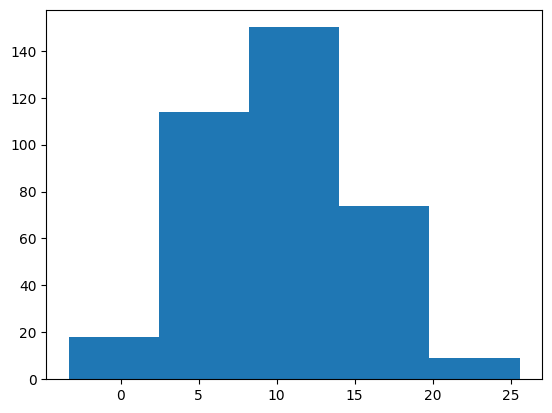

In [30]:
plt.hist(data=data_chl, x='chl', bins=5)

##  Индекс Шеннона, здесь в биологическом контексте

$p_{i}$ – отношение численности вида i к общему числу особей выборки N.
Индекс чувствителен как к числу видов, так и к неравномерности их количественной представленности в пробе (сообществе). 

Чаще всего в ситуации, когда $H`$ стремится к 3,5 (м.б. больше) – это говорит о высоком числе видов и высокой выровненности в сообществе (численности отличаются несильно). Если $H`$ стремится к 1,5 (м.б. меньше) – это говорит о низком числе видов и низкой выровненности в сообществе (численности отличаются сильно)

Shannon C.E., Weawer W. The mathematical theory of communication. Urbana: University of Illinois Press. 1963. - 125 p.

$$H=-\sum\limits_{i=1}^np_{i}log_{2}p_{i}$$

### Синтетические данные, чтобы посмотреть как ведет себя индекс при большом видовом разнообразии

In [31]:
sizes = [1, 4, 10, 50, 100, 200, 300, 500, 1000, 2000, 3000, 5000, 10000]
siz = np.log(sizes)
name_col = [str(i) for i in range(1,4)]
sh = []
scale = 100
loc = 0

for a in sizes:
    print(a)
    '''
    data = pd.DataFrame({name_col[0]: expon.rvs(loc=loc, scale= scale, size= a), 
                         name_col[1]: expon.rvs(loc=loc, scale= scale, size= a), 
                         name_col[2]: expon.rvs(loc=loc, scale= scale, size= a)})
    '''
    data = pd.DataFrame({name_col[0]: np.random.exponential(scale= scale, size= a), 
                         name_col[1]: np.random.exponential(scale= scale, size= a), 
                         name_col[2]: np.random.exponential(scale= scale, size= a)})
    [print(-np.sum(data[i].dropna().apply(lambda x: x/np.sum(data[i].dropna()) * np.log(x/np.sum(data[i].dropna()))))) for i in data.columns]
    sh.append(-np.sum(data['1'].dropna().apply(lambda x: x/np.sum(data['1'].dropna()) * np.log(x/np.sum(data['1'].dropna())))))

1
-0.0
-0.0
-0.0
4
1.1620185257080158
1.0498245406016697
1.1687860386420108
10
1.8928948537676686
1.862453483708255
1.9678161009478956
50
3.5085737247586724
3.3678186747684657
3.409976811552611
100
4.216957960518655
4.174259165944735
4.249343560977125
200
4.84468032882371
4.84492761827161
4.856269009847569
300
5.257763868489381
5.293903489224018
5.294703360165284
500
5.794565138890068
5.7692424992390325
5.81856140361614
1000
6.4761465802827916
6.513844163868144
6.515562434598835
2000
7.158278834334264
7.175435423367709
7.174305722801993
3000
7.595289094316529
7.577334903096347
7.587140626542976
5000
8.100605252384398
8.085407391915535
8.096980846600738
10000
8.787270254394034
8.784073177764407
8.788732488487003


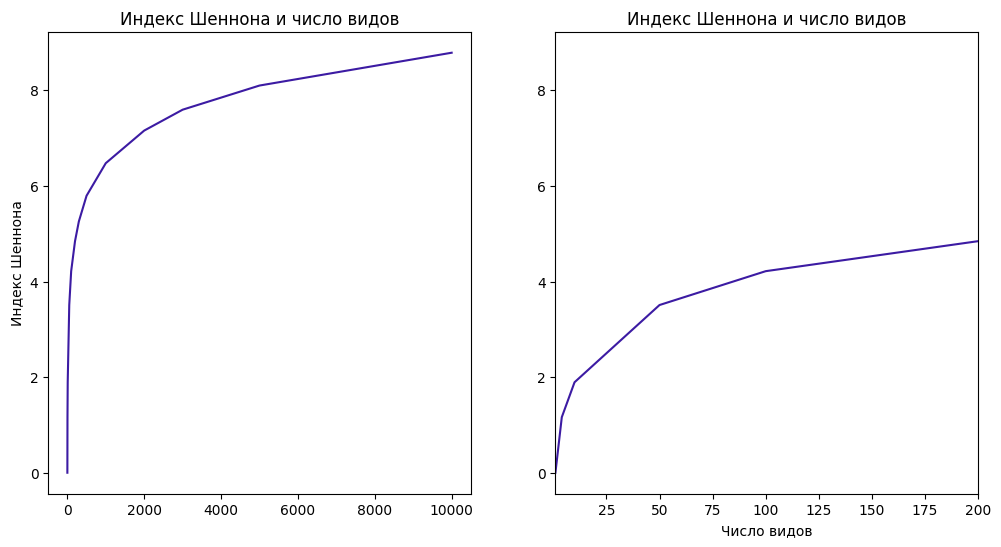

In [32]:
plt.figure(figsize=(12, 6))

plt.subplot(121)
plt.plot(sizes, sh, color='#3C1BA3')
plt.title('Индекс Шеннона и число видов')
plt.ylabel('Индекс Шеннона')

plt.subplot(122)
plt.plot(sizes, sh, color='#3C1BA3')
plt.xlim(1, 200)
plt.xlabel('Число видов')
plt.title('Индекс Шеннона и число видов')

plt.savefig('02_pictures/01_sh_by_size.jpg', bbox_inches='tight')

In [33]:
shan = pd.DataFrame({'Number_of_species': sizes, 'Shannon': sh})
shan

,Number_of_species,Shannon
0,1,-0.000000
1,4,1.162019
2,10,1.892895
3,50,3.508574
4,100,4.216958
5,200,4.844680
6,300,5.257764
7,500,5.794565
8,1000,6.476147
9,2000,7.158279


## Индекс Пиелу

Индекс выравненности Пиелу $J`$:

$H`$ - индекс Шеннона, S – число видов в сообществе. Индекс зависит лишь от равномерности распределения обилий видов, меняется в диапазоне от 0 - абсолютное доминирование единственного вида до 1 (все виды характеризуются равномерным числом особей) (Pielou, 1966).


Pielou E.C. Shannon's formula as a measure of specific diversity and its use and misuse // The American Naturalist. 1966. Vol. 100. № 914. - P. 463-465.

$$J`={\frac{H`}{log(S)}}$$

In [34]:
shan['Pielou'] = [shan['Shannon'][i] / np.log(shan['Number_of_species'][i]) for i in range(shan.shape[0])]
shan

C:\Users\vladk\AppData\Local\Temp\ipykernel_4792\1150054486.py:1: RuntimeWarning: invalid value encountered in scalar divide
  shan['Pielou'] = [shan['Shannon'][i] / np.log(shan['Number_of_species'][i]) for i in range(shan.shape[0])]


,Number_of_species,Shannon,Pielou
0,1,-0.000000,NaN
1,4,1.162019,0.838219
2,10,1.892895,0.822074
3,50,3.508574,0.896869
4,100,4.216958,0.915701
5,200,4.844680,0.914381
6,300,5.257764,0.921803
7,500,5.794565,0.932410
8,1000,6.476147,0.937518
9,2000,7.158279,0.941767
